## Imports

In [1]:
import copy
import salvus.namespace as sn
import numpy as np
import matplotlib.pyplot as plt

import sys
import importlib
from pathlib import Path
path_to_add = str(Path.cwd() / "tomography")
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

import my_code.utilities
importlib.reload(my_code.utilities)
from my_code.utilities import *
import salvus

import salvus.mesh.layered_meshing as lm
from datetime import datetime
import salvus.flow.simple_config as sc
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)

import xarray as xr

--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.48 seconds]


## Configuration, project and mesh

In [12]:
# ---- Salvus site --------------------------------------------------------
SITE_NAME = "isambard_oliver"
RANKS = 8

# ---- Physical parameters ------------------------------------------------
CENTRAL_FREQUENCY = 2e4   # Hz
f_c               = 2e4   # centre frequency [Hz]
VP                = 5000.0
RHO               = 2600.0

# ---- Domain -------------------------------------------------------------
x0, x1 = 0.0, 1.0
y0, y1 = 0.0, 1.0

# ---- Project ------------------------------------------------------------
PROJECT_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project'
DATA_DIR_WIN    = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/data'
IMAGE_DIR_WIN   = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/image'

Path(PROJECT_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(IMAGE_DIR_WIN).mkdir(parents=True, exist_ok=True)

PROJECT_NAME = 'acoustic_forward_5paris'
domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR_WIN, PROJECT_NAME), domain=domain, load_if_exists=True
)

# ---- Mesh resolution ----------------------------------------------------
elements_per_wavelength = 3
model_order             = 4
reference_velocity      = 5000
number_of_wavelengths   = 2
reference_frequency     = CENTRAL_FREQUENCY * 2
free_surfaces           = ['y0', 'y1']

# ---- True (layered) model -----------------------------------------------
m_true = sn.layered_meshing.LayeredModel([
    sn.material.from_params(rho=RHO, vp=VP),
    sn.layered_meshing.interface.Hyperplane.at(0.6),
    sn.material.from_params(rho=RHO, vp=1.5 * VP),
    sn.layered_meshing.interface.Hyperplane.at(0.4),
    sn.material.from_params(rho=RHO, vp=VP),
])

# ---- Homogeneous starting model -----------------------------------------
m_homo = sn.material.from_params(rho=RHO, vp=VP)

ab_params = salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
    free_surface=free_surfaces,
    number_of_wavelengths=number_of_wavelengths,
    reference_velocity=reference_velocity,
    reference_frequency=reference_frequency,
)

mesh_res = sn.MeshResolution(
    reference_frequency=reference_frequency,
    elements_per_wavelength=elements_per_wavelength,
    model_order=model_order,
)

mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_homo, ab=ab_params),
    mesh_resolution=mesh_res,
)

mesh = lm.mesh_from_domain(
    domain=domain,
    model=sn.layered_meshing.MeshingProtocol(m_true, ab=ab_params),
    mesh_resolution=mesh_res,
)
mesh

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-03-26 00:19:57,458] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_5paris.


In [131]:
# VP_elemental = elemental_nodal_to_elemental_field(mesh.element_nodal_fields['VP'], mesh)

# print("ENF shape      :", mesh.element_nodal_fields['VP'].shape)
# print("Elemental shape:", VP_elemental.shape)
# print(f"VP stats — min: {VP_elemental.min():.1f}  max: {VP_elemental.max():.1f}  mean: {VP_elemental.mean():.1f}")


# centroids = mesh.get_element_centroid()   # (nelem, 2)
# x_c, y_c = centroids[:, 0], centroids[:, 1]

# roi_elem = (x_c >= x0) & (x_c <= x1) & (y_c >= y0) & (y_c <= y1)

# x_r = x_c[roi_elem]
# y_r = y_c[roi_elem]
# vp_r = VP_elemental[roi_elem]

# # Reshape to 2-D grid
# xs = np.unique(x_r)
# ys = np.unique(y_r)
# nx, ny = len(xs), len(ys)

# idx = np.lexsort((x_r, y_r))          # sort by y then x
# VP_2d = vp_r[idx].reshape(ny, nx)
# X_2d  = x_r[idx].reshape(ny, nx)
# Y_2d  = y_r[idx].reshape(ny, nx)

# fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
# pm = ax.pcolormesh(X_2d, Y_2d, VP_2d, cmap='viridis', shading='nearest')
# plt.colorbar(pm, ax=ax, label='VP [m/s]')
# ax.set_xlabel('X [m]')
# ax.set_ylabel('Y [m]')
# ax.set_title(f'VP')
# ax.set_aspect('equal')
# plt.tight_layout()
# plt.show()

## Source / receiver setup

In [103]:
# event_single = 'single_pair'

# amplitude_ratio = 1e5
# s_loc = (0.5, 0.3)
# r_loc = [(0.5, 0.7)]

# receivers = [
#     sn.simple_config.receiver.cartesian.Point2D(
#         x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
#     )
#     for j, r in enumerate(r_loc)
# ]
# source = sn.simple_config.source.cartesian.ScalarPoint2D(
#     x=s_loc[0], y=s_loc[1], f=amplitude_ratio
# )

# p.add_to_project(
#     sn.Event(event_name=event_single, sources=source, receivers=receivers)
# )

In [3]:
event_5p = '5_pairs'
amplitude_ratio = 1e3

s_loc = (0.5, 0.3)
r_loc = [(x, 0.7) for x in np.linspace(0.2, 0.8, 5)]

receivers = [
    sn.simple_config.receiver.cartesian.Point2D(
        x=r[0], y=r[1], station_code=f"R{j+1}", fields=["phi"]
    )
    for j, r in enumerate(r_loc)
]
source = sn.simple_config.source.cartesian.ScalarPoint2D(
    x=s_loc[0], y=s_loc[1], f=amplitude_ratio
)
p.add_to_project(
    sn.Event(event_name=event_5p, sources=source, receivers=receivers)
)


## Simulation configurations

In [4]:
end_time               = 2e-4
start_time             = 0
sampling_rate_in_hertz = CENTRAL_FREQUENCY * 100
time_shift_in_seconds  = 1 / f_c

wavelet = sn.simple_config.stf.Ricker(
    center_frequency=f_c,
    time_shift_in_seconds=time_shift_in_seconds,
)

waveform_config = sn.WaveformSimulationConfiguration(
    start_time_in_seconds=start_time,
    end_time_in_seconds=end_time,
    time_step_in_seconds=1 / sampling_rate_in_hertz,
)

event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
)

# Homogeneous (starting) model
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh_homo,
        name='forward_simulation_homogeneous_model',
        event_configuration=event_config,
    ),
    overwrite=True,
)

# True (layered) model — used to generate observed data
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh,
        name='forward_simulation_layred_model',
        event_configuration=event_config,
    ),
    overwrite=True,
)

## Helper functions

In [5]:
def forward_simulation(simulation_name, events,
                       fields=None, sampling_interval_in_time_steps=10):
    if fields:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            extra_output_configuration={
                "volume_data": {
                    "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                    "fields": fields,
                },
            },
            delete_conflicting_previous_results=True,
        )
    else:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            delete_conflicting_previous_results=True,
        )
    p.simulations.query(block=True)



def extract_data(simulation, events, receiver_field='phi', field=None):
    ed = p.waveforms.get(data_name=simulation, events=events)[0]
    data = ed.get_waveform_data_xarray(receiver_field=receiver_field)
    wavefield = None
    if field:
        wavefield = wavefield_output_to_xarray(
            ed.get_wavefield_output(output_type='volume', field=field),
            p.simulations.get_mesh(simulation).points,
        ).T
    return data, wavefield


def misfit_adjoint_source(u_obs, u, event=False, iteration=0):
    sampling_rate = u_obs.sampling_rate_in_hertz
    start_time    = u_obs.time[0]
    end_time      = u_obs.time[-1]

    diff   = u_obs - u
    misfit = 0.5 / sampling_rate * (diff ** 2).sum()
    f_adj  = np.flip(diff, axis=1)

    event_adj        = None
    event_config_adj = None

    if event:
        rxs, srcs    = p.events.get(event).receivers, p.events.get(event).sources
        rxs_adj_loc  = [r.location for r in srcs]
        src_adj_loc  = [t.location for t in rxs]

        stf_adj_ls = [
            sc.stf.Custom.from_array(
                np.array(f_adj[i]),
                sampling_rate_in_hertz=sampling_rate_in_hertz,
                start_time_in_seconds=0.0,
            )
            for i in range(len(src_adj_loc))
        ]

        srcs_adj = [
            sn.simple_config.source.cartesian.ScalarPoint2D(x=tx[0], y=tx[1], f=1)
            for tx in src_adj_loc
        ]
        rxs_adj = [
            sn.simple_config.receiver.cartesian.Point2D(
                x=rx[0], y=rx[1],
                fields=['phi'],
                station_code=f"ite:{iteration}_adj_{_i:06d}",
            )
            for _i, rx in enumerate(rxs_adj_loc)
        ]

        event_adj = f'{event}_adjoint_{iteration}'
        p.add_to_project(sn.Event(event_name=event_adj, sources=srcs_adj, receivers=rxs_adj))

        event_config_adj = sn.EventConfiguration(
            wavelet=stf_adj_ls,
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=start_time,
                end_time_in_seconds=end_time,
                time_step_in_seconds=1 / sampling_rate_in_hertz,
            ),
        )

    return misfit, f_adj, event_adj, event_config_adj


def adjoint_wavefield(p, event_adj, event_config_adj,
                      model_simulation_name='forward_simulation_homogeneous_model',
                      field='phi', iteration=0,
                      sampling_interval_in_time_steps=10):
    simulation_adj  = f"adjoint_{iteration}"
    mesh_current    = p.simulations.get_mesh(model_simulation_name)

    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            unstructured_mesh=mesh_current,
            name=simulation_adj,
            event_configuration=event_config_adj,
        ),
        overwrite=True,
    )

    p.simulations.launch(
        ranks_per_job=RANKS,
        site_name=SITE_NAME,
        events=event_adj,
        simulation_configuration=simulation_adj,
        extra_output_configuration={
            "volume_data": {
                "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                "fields": [field],
            },
        },
        delete_conflicting_previous_results=True,
    )
    p.simulations.query(block=True)

    _, wavefield_adj = extract_data(
        simulation=simulation_adj,
        events=event_adj,
        receiver_field='phi',
        field=field,
    )
    return wavefield_adj


def compute_gradient(forward_wavefield, adjoint_wavefield):
    """
    Sensitivity kernel K_A = ∂J/∂A  (zero-lag cross-correlation):

        K_A(x) = Σ_t φ†(x, T-t) · φ_tt(x, t) · Δt

    φ† is time-reversed before the inner product because the adjoint
    simulation runs forward in time (source = time-reversed residual).

    Parameters
    ----------
    forward_wavefield : xarray   φ_tt  shape (nodes, T)
    adjoint_wavefield : xarray   φ†    shape (nodes, T_adj)

    Returns
    -------
    K_A : np.ndarray, shape (n_nodes,)   ∂J/∂A
    """
    fwd = forward_wavefield.values.squeeze()    # (nodes, T)
    adj = adjoint_wavefield.values.squeeze()    # (nodes, T_adj)

    t_coord = forward_wavefield.coords.get('t', forward_wavefield.coords.get('time'))
    t_fwd   = t_coord.values
    dt      = float(t_fwd[1] - t_fwd[0])

    # Interpolate adjoint onto forward time axis if sampling strides differ
    if adj.shape[-1] != fwd.shape[-1]:
        from scipy.interpolate import interp1d
        t_adj = adjoint_wavefield.coords.get('t', adjoint_wavefield.coords.get('time')).values
        adj   = interp1d(t_adj, adj, axis=-1, kind='linear',
                         bounds_error=False, fill_value=0.0)(t_fwd)

    # Time-reverse φ† → φ†(T-t), then dot with φ_tt(t)
    adj_flipped = np.flip(adj, axis=-1)                          # φ†(x, T-t)
    return np.einsum('nt,nt->n', adj_flipped, fwd) * dt          # (n_nodes,)

## Run initial simulations

Simulate the **true (layered) model** to generate observed data, and the **homogeneous model** with φ_tt volume output as the FWI starting point.

In [7]:
t0 = datetime.now()
event = event_5p

# True model → observed data
forward_simulation(
    simulation_name='forward_simulation_layred_model',
    events=event,
    fields=None,
)
# p.simulations.query(block=True)

# Homogeneous model → starting synthetic + φ_tt wavefield
forward_simulation(
    simulation_name='forward_simulation_homogeneous_model',
    events=event,
    fields=['phi_tt'],
    sampling_interval_in_time_steps=10,
)
# p.simulations.query(block=True)

elapsed = (datetime.now() - t0).total_seconds()
print(f"Initial simulations done in {int(elapsed//60)}m {elapsed%60:.1f}s")

[2026-03-25 22:11:35,872] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2603252211947963_3f3cda7574@isambard_oliver


VBox()

/local/user/1483804793/ipykernel_56394/1930470684.py:25: UserWarning: Deleting directory /home/b6as/oliverwfy.b6as/salvus_data/run_directory/job_2603252211947963_3f3cda7574 on site isambard_oliver failed. Reason for the failure: local variable 'e' referenced before assignment
  p.simulations.query(block=True)


[2026-03-25 22:11:46,157] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2603252211162545_e2a103669d@isambard_oliver


VBox()

Initial simulations done in 0m 22.2s


## Adjoint source, adjoint wavefield and sensitivity kernel (iteration 0)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

L2 Misfit (iteration 0): 1.733502e+06
[2026-03-25 22:12:00,334] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603252212344086_02ed924efc@isambard_oliver


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

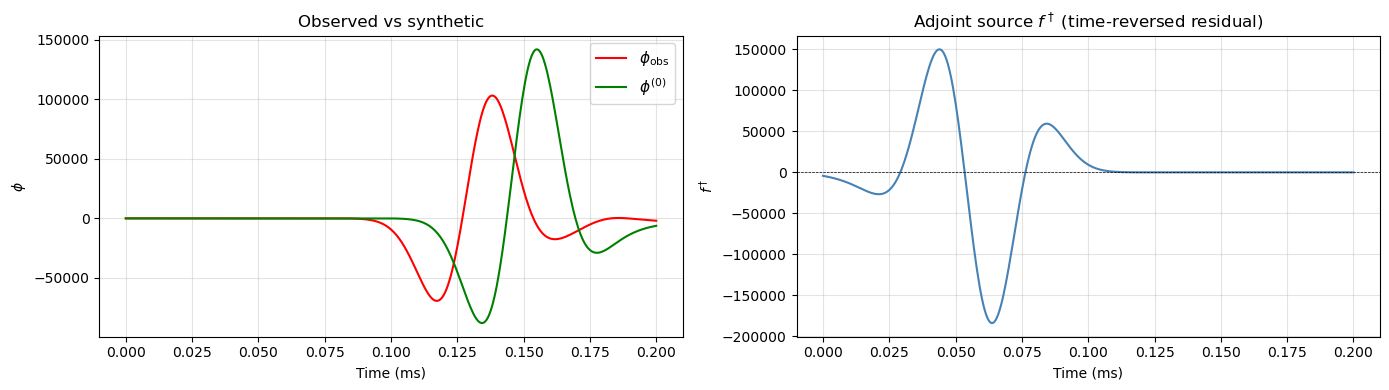

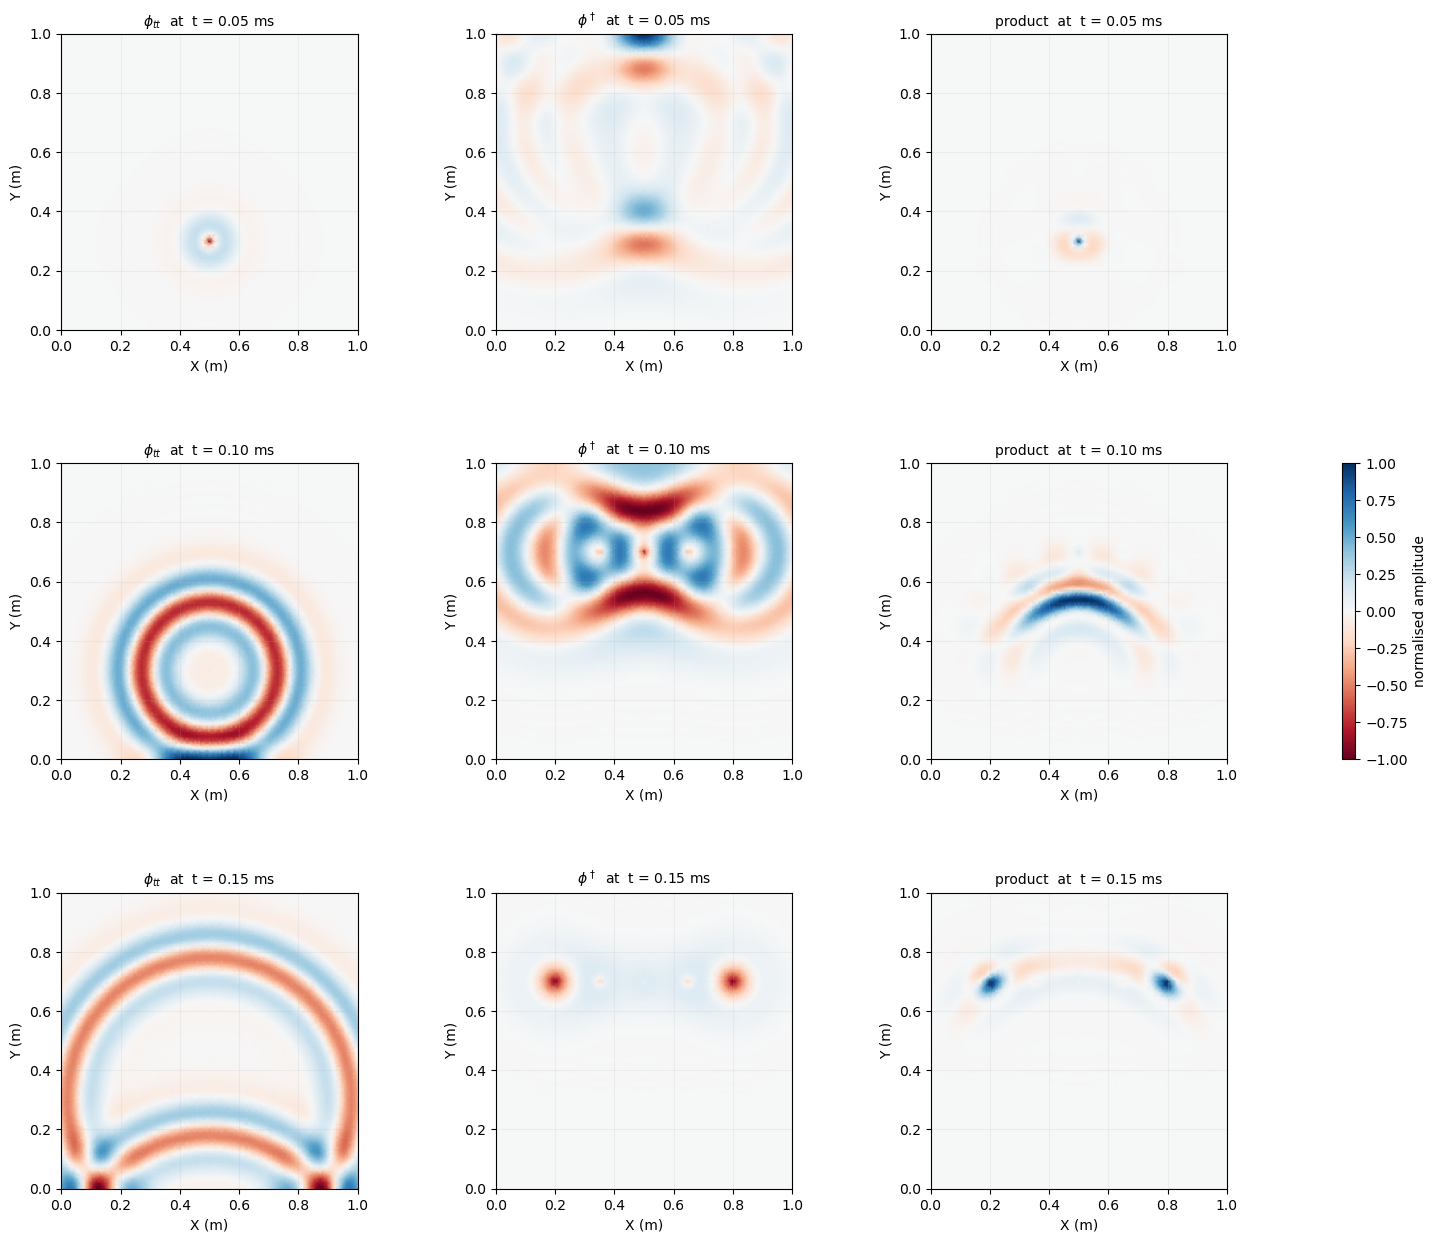

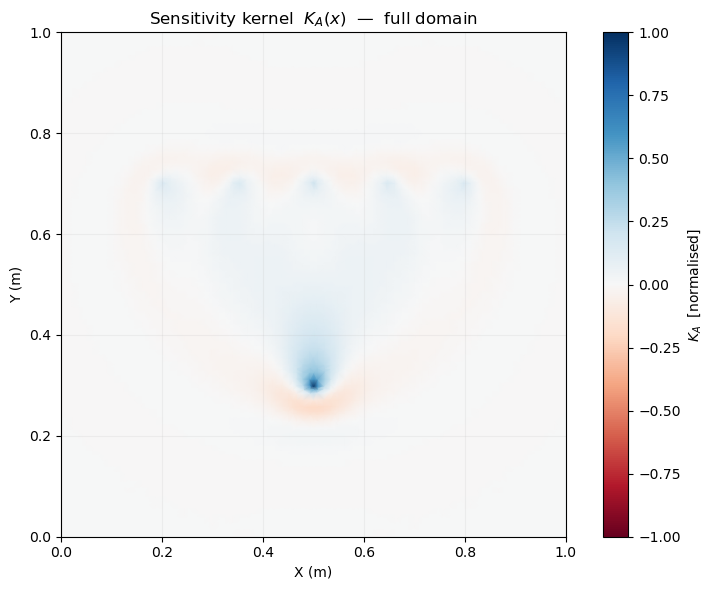

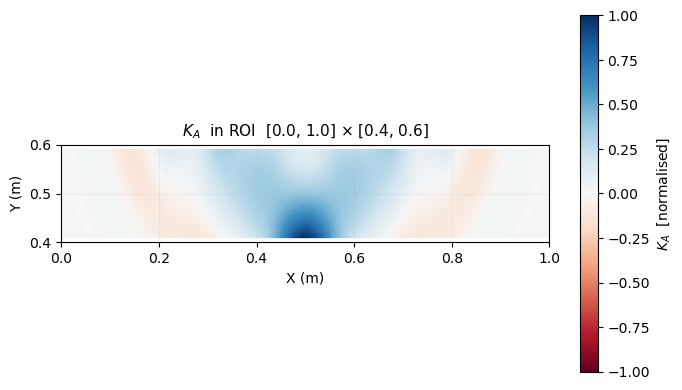

In [8]:
# ── 1. Extract initial synthetic data and φ_tt wavefield ─────────────────
phi_homo, phi_tt = extract_data(
    simulation='forward_simulation_homogeneous_model',
    events=event,
    receiver_field='phi',
    field='phi_tt',
)

phi_obs, _ = extract_data(
    simulation='forward_simulation_layred_model',
    events=event,
    receiver_field='phi',
    field=None,
)

# ── 2. Adjoint source ─────────────────────────────────────────────────────
misfit, f_adj, event_adj, event_config_adj = misfit_adjoint_source(
    phi_obs, phi_homo, event=event, iteration=0,
)
print(f"L2 Misfit (iteration 0): {float(misfit):.6e}")

# ── 3. Adjoint wavefield φ† ───────────────────────────────────────────────
phi_adj = adjoint_wavefield(
    p, event_adj, event_config_adj,
    model_simulation_name='forward_simulation_homogeneous_model',
    field='phi',
    iteration=0,
    sampling_interval_in_time_steps=10,
)

# ── 4. Mesh, node coordinates and VP nodal field ─────────────────────────
mesh_viz = p.simulations.get_mesh('forward_simulation_homogeneous_model')
x, y     = mesh_viz.points[:, 0], mesh_viz.points[:, 1]
# ── 5. Sensitivity kernel K_A(x) — full mesh, then extract ROI ──────────
ROI = (0.0, 1.0, 0.4, 0.6)                          # (x0, x1, y0, y1)
K = compute_gradient(phi_tt, phi_adj)               # shape (nodes,) ∂J/∂A

x0, x1, y0, y1 = ROI
roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
K_roi    = K[roi_mask]
x_roi    = x[roi_mask]
y_roi    = y[roi_mask]

# ── 6. Prepare arrays ─────────────────────────────────────────────────────
time_wf    = phi_homo.time.values

fwd = phi_tt.values.squeeze()
adj = phi_adj.values.squeeze()

t_fwd = phi_tt.coords.get('t', phi_tt.coords.get('time')).values
t_adj = phi_adj.coords.get('t', phi_adj.coords.get('time')).values
if adj.shape[-1] != fwd.shape[-1]:
    from scipy.interpolate import interp1d
    adj = interp1d(t_adj, adj, axis=-1, kind='linear',
                   bounds_error=False, fill_value=0.0)(t_fwd)

adj_flipped = np.flip(adj, axis=-1)

T         = fwd.shape[-1]
dt        = float(t_fwd[1] - t_fwd[0])
t_indices = [T // 4, T // 2, 3 * T // 4]

def snap_clim(arr):
    v = np.percentile(np.abs(arr), 98)
    return dict(vmin=-v, vmax=v)

def normalize(arr):
    """Normalise to [-1, 1]."""
    m = np.nanmax(np.abs(arr))
    return arr / m if m > 0 else arr

# ── 7. Figure 1 — waveforms and adjoint source ────────────────────────────
fig1, axs = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

axs[0].plot(time_wf * 1e3, np.array(phi_obs[0]),  color='red',   lw=1.5, label=r'$\phi_\mathrm{obs}$')
axs[0].plot(time_wf * 1e3, np.array(phi_homo[0]), color='green', lw=1.5, label=r'$\phi^{(0)}$')
axs[0].legend(fontsize=11)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel(r'$\phi$')
axs[0].set_title('Observed vs synthetic')
axs[0].grid(alpha=0.35)

axs[1].plot(time_wf * 1e3, np.array(-f_adj[0]), color='steelblue', lw=1.5)
axs[1].axhline(0, color='k', lw=0.5, ls='--')
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel(r'$f^\dagger$')
axs[1].set_title(r'Adjoint source $f^\dagger$ (time-reversed residual)')
axs[1].grid(alpha=0.35)

plt.tight_layout()
plt.show()

# ── 8. Figure 2 — how K is built: φ_tt | φ†(T-t) | product per time step ─
from matplotlib.gridspec import GridSpec

fig2 = plt.figure(figsize=(17, 15), dpi=100)
gs = GridSpec(3, 4, figure=fig2, width_ratios=[1, 1, 1, 0.04],
              hspace=0.45, wspace=0.35)
axes = [[fig2.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]
cax  = fig2.add_subplot(gs[1, 3])

col_titles = [r'$\phi_{tt}(x,\,t)$  [normalised]',
              r'$\phi^\dagger(x,\,T{-}t)$  [normalised]',
              r'$\phi_{tt}\;\cdot\;\phi^\dagger$  [normalised]']

for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=12, pad=8)

tp_last = None
for row, ti in enumerate(t_indices):
    t_ms = t_fwd[ti] * 1e3

    s_fwd  = normalize(fwd[:, ti])
    s_adj  = normalize(adj_flipped[:, ti])
    s_prod = normalize(s_fwd * s_adj)

    for col, (snap, label) in enumerate([(s_fwd,  r'$\phi_{tt}$'),
                                          (s_adj,  r'$\phi^\dagger$'),
                                          (s_prod, 'product')]):
        ax = axes[row][col]
        tp = ax.tripcolor(x, y, snap, cmap='RdBu', shading='gouraud',
                          vmin=-1, vmax=1)
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_title(f'{label}  at  t = {t_ms:.2f} ms', fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.grid(alpha=0.15)
        if row == 1 and col == 2:
            tp_last = tp

fig2.colorbar(tp_last, cax=cax, label='normalised amplitude')
plt.show()

# ── 9. Figure 3 — full sensitivity kernel K(x) ───────────────────────────
fig3, ax_K = plt.subplots(figsize=(8, 6), dpi=100)
tp = ax_K.tripcolor(x, y, normalize(K), cmap='RdBu', shading='gouraud', vmin=-1, vmax=1)
plt.colorbar(tp, ax=ax_K, label='$K_A$  [normalised]')
ax_K.set_xlabel('X (m)')
ax_K.set_ylabel('Y (m)')
ax_K.set_title(r'Sensitivity kernel  $K_A(x)$  —  full domain', fontsize=12)
ax_K.set_xlim(0, 1)
ax_K.set_ylim(0, 1)
ax_K.set_aspect('equal')
ax_K.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# ── 10. Figure 4 — K(x) within ROI ──────────────────────────────────────
fig4, ax_2d = plt.subplots(figsize=(7, 4), dpi=100)
tp = ax_2d.tripcolor(x_roi, y_roi, normalize(K_roi),
                     cmap='RdBu', shading='gouraud', vmin=-1, vmax=1)
plt.colorbar(tp, ax=ax_2d, label='$K_A$  [normalised]')
ax_2d.set_xlabel('X (m)')
ax_2d.set_ylabel('Y (m)')
ax_2d.set_title(f'$K_A$  in ROI  [{x0}, {x1}] × [{y0}, {y1}]', fontsize=11)
ax_2d.set_xlim(x0, x1)
ax_2d.set_ylim(y0, y1)
ax_2d.set_aspect('equal')
ax_2d.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [109]:
# import time
# # compare sensitivity kernel with Salvus's built-in gradient computation
# p.add_to_project(
#     sn.MisfitConfiguration(
#         name="L2",
#         observed_data="forward_simulation_layred_model",
#         misfit_function="L2",
#         receiver_field=f'phi',
#     )
# )


# while not p.actions.inversion.compute_misfits(
#     simulation_configuration="forward_simulation_homogeneous_model", 
#     misfit_configuration="L2", 
#     events=event,
#     site_name=SITE_NAME,
#     ranks_per_job = 4
# ): time.sleep(10.0)


# while not p.actions.inversion.compute_gradients(
#     simulation_configuration="forward_simulation_homogeneous_model",
#     misfit_configuration="L2",
#     wavefield_compression=sn.WavefieldCompression(
#         forward_wavefield_sampling_interval=10
#     ),
#     events=event,
#     site_name=SITE_NAME,
#     ranks_per_job=4,
# ): time.sleep(10.0)



# p.viz.nb.gradients(
#     simulation_configuration="forward_simulation_homogeneous_model",
#     misfit_configuration="L2",
#     wavefield_compression=sn.WavefieldCompression(
#         forward_wavefield_sampling_interval=10
#     ),
#     events=event,
# )

In [9]:
# ── Outer-scope setup ────────────────────────────────────────────────────
VP_MIN, VP_MAX  = VP * 0.5, VP * 1.5
A_MIN, A_MAX    = 1.0 / VP_MAX**2, 1.0 / VP_MIN**2
SAMPLING_INTERVAL = 10

obs_simulation  = 'forward_simulation_layred_model'
init_simulation = 'forward_simulation_homogeneous_model'

base_mesh = copy.deepcopy(p.simulations.get_mesh(init_simulation))

phi_obs, _ = extract_data(
    simulation=obs_simulation, events=event, receiver_field='phi', field=None,
)

event_config_fwd = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
        start_time_in_seconds=0,
        end_time_in_seconds=end_time,
        time_step_in_seconds=1 / sampling_rate_in_hertz,
    ),
)

# nodal ROI mask — one entry per global node
_x, _y  = base_mesh.points[:, 0], base_mesh.points[:, 1]
x0_roi, x1_roi, y0_roi, y1_roi = ROI
roi_mask = (_x >= x0_roi) & (_x <= x1_roi) & (_y >= y0_roi) & (_y <= y1_roi)

_fwi_iter = [0]   # L-BFGS-B iteration counter (incremented in callback)
_fwi_ls   = [0]   # line-search step counter within current iteration (reset in callback)

# ── Objective function ────────────────────────────────────────────────────
def objective(m_flat):
    """
    FWI objective for L-BFGS-B.

    Parameters
    ----------
    m_flat : np.ndarray, shape (n_roi_nodes,)
        Model vector: A = 1/VP² at each ROI node.

    Returns
    -------
    misfit : float
    grad   : np.ndarray, shape (n_roi_nodes,)   ∂J/∂A  per ROI node, normalised by max |grad|
    """
    it      = _fwi_iter[0]
    ls      = _fwi_ls[0]
    _fwi_ls[0] += 1
    sim_name = f'fwi_{it:03d}_grad' if ls == 0 else f'fwi_{it:03d}_ls_{ls}'

    m = np.clip(m_flat, A_MIN, A_MAX)

    # ── 0. ROI mask (nodal) ───────────────────────────────────────────────
    _xn, _yn = base_mesh.points[:, 0], base_mesh.points[:, 1]
    x0_roi, x1_roi, y0_roi, y1_roi = ROI
    roi_mask = (_xn >= x0_roi) & (_xn <= x1_roi) & (_yn >= y0_roi) & (_yn <= y1_roi)

    # ── 1. Build mesh: A → VP at nodes → ENF via connectivity ─────────────
    mesh_it  = copy.deepcopy(base_mesh)
    vp_nodal = elemental_nodal_to_nodal_field(
        mesh_it.element_nodal_fields['VP'], mesh_it.connectivity
    ).copy()
    vp_nodal[roi_mask] = np.clip(1.0 / np.sqrt(np.maximum(m, 1e-30)), VP_MIN, VP_MAX)
    mesh_it.element_nodal_fields['VP'] = vp_nodal[mesh_it.connectivity]

    # ── 2. Register and run forward simulation ────────────────────────────
    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            unstructured_mesh=mesh_it,
            name=sim_name,
            event_configuration=event_config_fwd,
        ),
        overwrite=True,
    )
    forward_simulation(sim_name, event,
                       fields=['phi_tt'],
                       sampling_interval_in_time_steps=SAMPLING_INTERVAL)
    # p.simulations.query(block=True)

    phi_syn, phi_tt_it = extract_data(
        sim_name, event, receiver_field='phi', field='phi_tt',
    )

    # ── 3. Misfit + adjoint source ────────────────────────────────────────
    misfit, _, event_adj, event_config_adj = misfit_adjoint_source(
        phi_obs, phi_syn, event=event, iteration=sim_name,
    )

    # ── 4. Adjoint simulation ─────────────────────────────────────────────
    phi_adj_it = adjoint_wavefield(
        p, event_adj, event_config_adj,
        model_simulation_name=sim_name,
        field='phi', iteration=sim_name,
        sampling_interval_in_time_steps=SAMPLING_INTERVAL,
    )

    # ── 5. Gradient: K_A = ∂J/∂A, restrict to ROI ───────────────────────────
    K_A   = compute_gradient(phi_tt_it, phi_adj_it)             # (n_nodes,) ∂J/∂A
    K_A   = np.where(np.isfinite(K_A), K_A, 0.0)               # sanitise inf/NaN
    grad  = K_A[roi_mask]                                        # (n_roi_nodes,)

    n_inf = np.sum(~np.isfinite(K_A))
    g_max = np.max(np.abs(grad))
    grad_norm = grad / g_max if g_max > 0 else grad
    label = 'grad' if ls == 0 else f'ls_{ls}'
    print(f"  iter {it:3d} {label:6s} | misfit = {float(misfit):.6e}"
          f" | K_A  max = {g_max:.3e}"
          f" | non-finite = {n_inf}")

    return float(misfit), grad_norm.ravel()

## FWI loop

## Visualise recovered model

[2026-03-26 00:15:23,134] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2603260015151775_f39d1d700d@isambard_oliver


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-26 00:15:36,830] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603260015838630_46b5310144@isambard_oliver


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

  iter   0 grad   | misfit = 1.733502e+06 | K_A  max = 9.617e+18 | non-finite = 0

CG init  |  misfit = 1.733502e+06  |  ||g||∞ = 1.000e+00


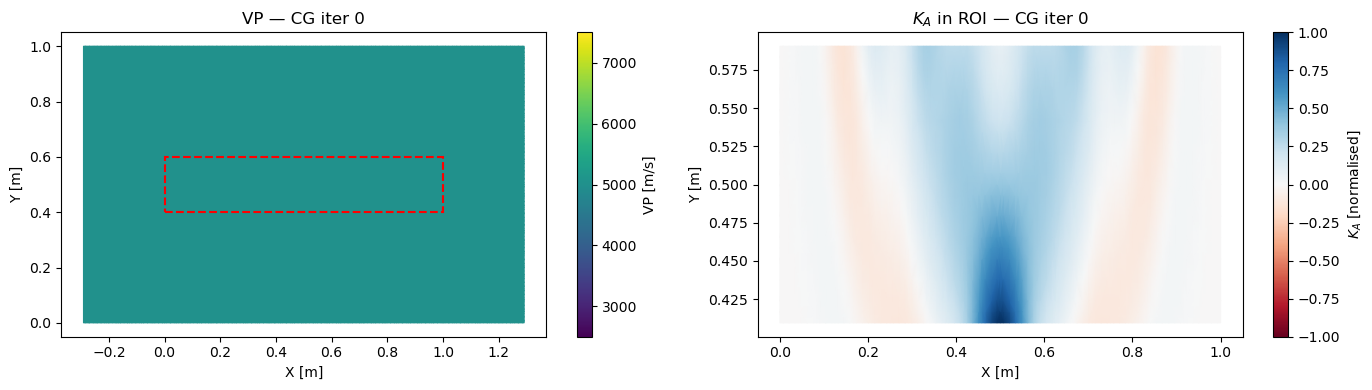

[2026-03-26 00:15:48,335] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-26 00:15:48,989] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603260015997998_4334fd88c6@isambard_oliver


...

VBox()

/local/user/1483804793/ipykernel_56394/1930470684.py:124: UserWarning: Deleting directory /home/b6as/oliverwfy.b6as/salvus_data/run_directory/job_2603260017033915_36065054e9 on site isambard_oliver failed. Reason for the failure: local variable 'e' referenced before assignment
  p.simulations.query(block=True)


Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

  iter   1 ls_7   | misfit = 1.733502e+06 | K_A  max = 9.617e+18 | non-finite = 0
  CG iter 1: line search reached max steps — accepting last trial

────────────────────────────────────────────────────────────
  CG iter   1  |  misfit = 1.733502e+06  |  α = 3.906e-06  |  β_PRP = 0.0000  |  LS steps = 8
────────────────────────────────────────────────────────────


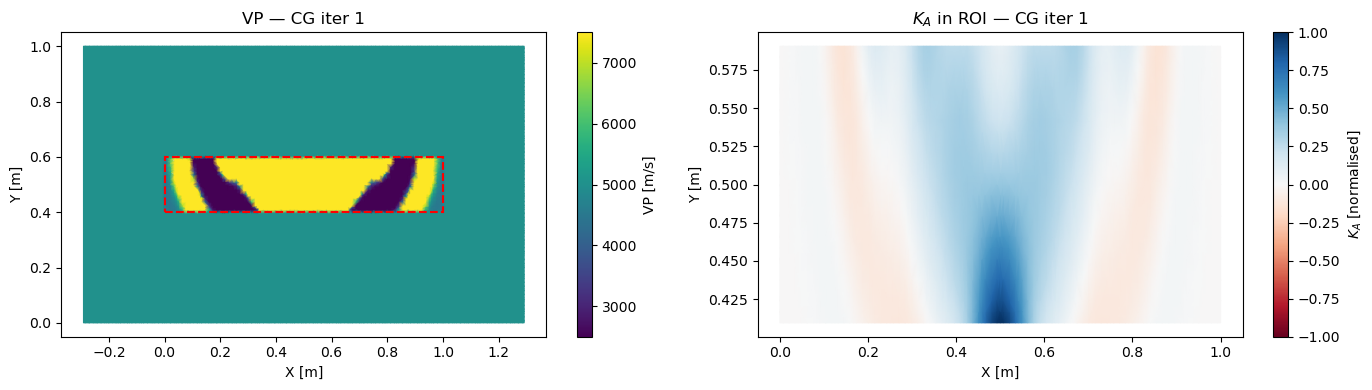

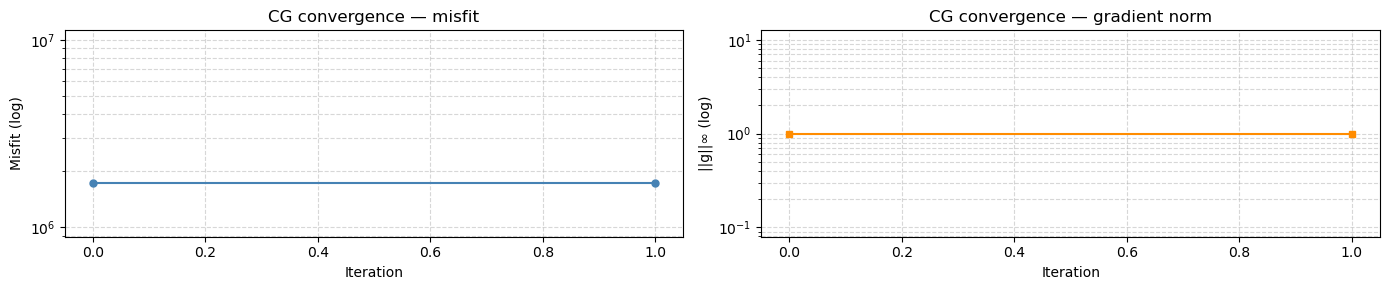

[2026-03-26 00:17:23,209] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-26 00:17:23,884] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603260017893700_4994da9e93@isambard_oliver


...

VBox()

/local/user/1483804793/ipykernel_56394/1930470684.py:124: UserWarning: Deleting directory /home/b6as/oliverwfy.b6as/salvus_data/run_directory/job_2603260018527440_7ef015a6e3 on site isambard_oliver failed. Reason for the failure: local variable 'e' referenced before assignment
  p.simulations.query(block=True)


Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

  iter   2 ls_7   | misfit = 1.733502e+06 | K_A  max = 9.617e+18 | non-finite = 0
  CG iter 2: line search reached max steps — accepting last trial

────────────────────────────────────────────────────────────
  CG iter   2  |  misfit = 1.733502e+06  |  α = 3.906e-06  |  β_PRP = 0.0000  |  LS steps = 8
────────────────────────────────────────────────────────────


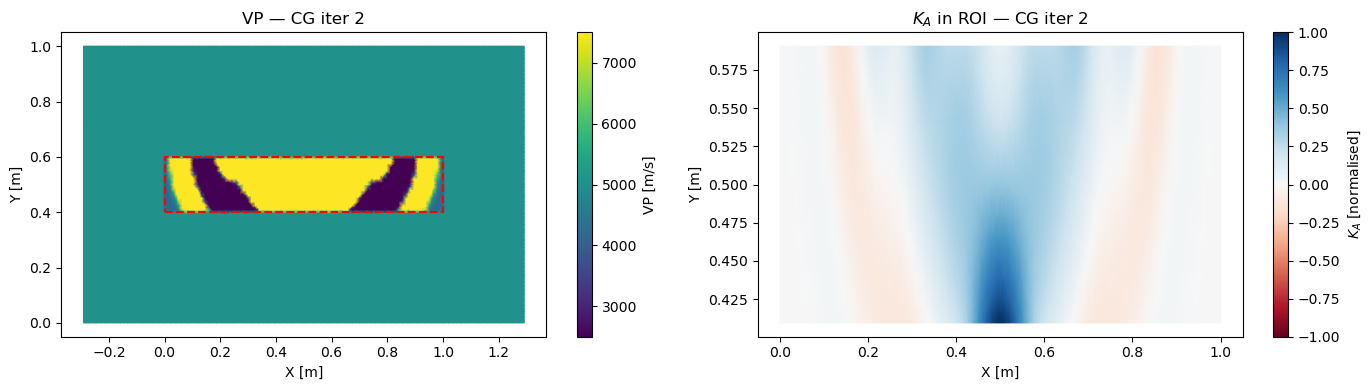

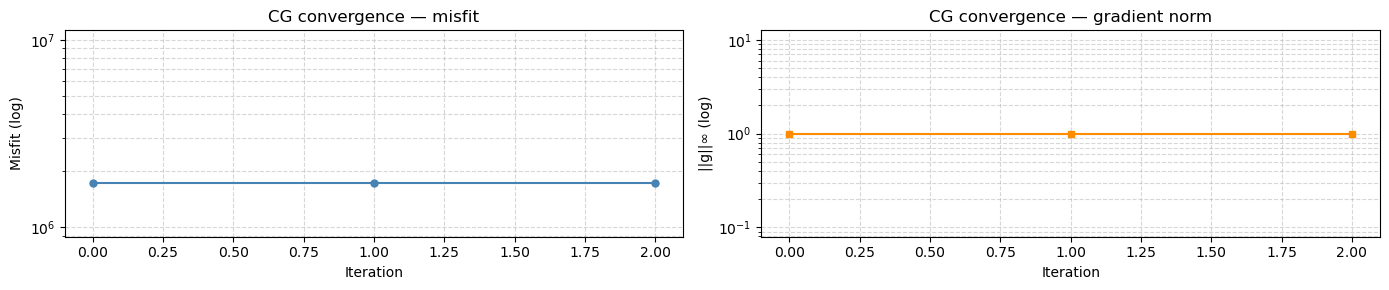

[2026-03-26 00:18:55,674] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().


VBox()

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-26 00:18:56,340] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603260018349174_096e758b8d@isambard_oliver


...

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-26 00:19:31,984] INFO: Submitting job ...
Uploading 6 files...

🚀  Submitted job_2603260019992936_02d753cf4d@isambard_oliver


VBox()

KeyboardInterrupt: 

In [11]:
# ── Nonlinear Conjugate Gradient (Polak-Ribière-Polyak, PRP+) ─────────────
#
# Each accepted CG iteration:
#   1. Evaluate gradient at current model (1 forward + 1 adjoint simulation)
#   2. Backtracking line search along conjugate direction (Armijo condition)
#      - each trial point: 1 forward + 1 adjoint simulation
#   3. Update model, compute PRP+ conjugate-direction coefficient β
#   4. Store misfit and normalised gradient; plot VP and K_A in ROI
#
# Parameterisation: A = 1/VP²  (bounds [A_MIN, A_MAX] enforced by clipping)
# ──────────────────────────────────────────────────────────────────────────

# ── Hyper-parameters ──────────────────────────────────────────────────────
CG_MAX_ITER = 10        # maximum CG iterations
CG_ALPHA0   = 1e-3      # initial step-size (tune if VP changes look too large/small)
CG_SHRINK   = 0.5       # backtracking factor per line-search step
CG_ARMIJO   = 1e-4      # sufficient-decrease (Armijo) constant c₁
CG_MAX_LS   = 8         # maximum backtracking steps per iteration
CG_GTOL     = 1e-6      # ||g||∞ stopping tolerance

# ── Storage ───────────────────────────────────────────────────────────────
cg_misfit_history = []   # misfit at each accepted model (index 0 = initial)
cg_grad_history   = []   # normalised K_A in ROI at each accepted model

# ── Helpers ───────────────────────────────────────────────────────────────
def _vp_from_A_cg(m_flat):
    """A-vector → clipped VP nodal values."""
    return np.clip(1.0 / np.sqrt(np.maximum(m_flat, 1e-30)), VP_MIN, VP_MAX)

def _plot_cg_iter(it, m_flat, grad_roi):
    """Side-by-side: VP on full mesh (with ROI box) and K_A in ROI."""
    xn, yn = base_mesh.points[:, 0], base_mesh.points[:, 1]
    x0_r, x1_r, y0_r, y1_r = ROI

    vp_nodal = elemental_nodal_to_nodal_field(
        base_mesh.element_nodal_fields['VP'], base_mesh.connectivity
    ).copy()
    vp_nodal[roi_mask] = _vp_from_A_cg(m_flat)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

    ax = axes[0]
    tc = ax.tripcolor(xn, yn, vp_nodal, cmap='viridis', shading='gouraud',
                      vmin=VP_MIN, vmax=VP_MAX)
    plt.colorbar(tc, ax=ax, label='VP [m/s]')
    ax.add_patch(plt.Rectangle((x0_r, y0_r), x1_r - x0_r, y1_r - y0_r,
                                edgecolor='red', facecolor='none', lw=1.5, ls='--'))
    ax.set_title(f'VP — CG iter {it}')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')

    ax = axes[1]
    tp = ax.tripcolor(xn[roi_mask], yn[roi_mask], grad_roi,
                      cmap='RdBu', shading='gouraud', vmin=-1, vmax=1)
    plt.colorbar(tp, ax=ax, label='$K_A$ [normalised]')
    ax.set_title(f'$K_A$ in ROI — CG iter {it}')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')

    plt.tight_layout()
    plt.savefig(f'{IMAGE_DIR_WIN}/cg_iter_{str(it).zfill(3)}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

def _plot_cg_convergence():
    """Misfit and ||g||∞ vs iteration."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 3), dpi=100)

    axes[0].semilogy(range(len(cg_misfit_history)), cg_misfit_history,
                     'o-', ms=5, color='steelblue')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Misfit (log)')
    axes[0].set_title('CG convergence — misfit')
    axes[0].grid(True, which='both', ls='--', alpha=0.5)

    grad_norms = [float(np.max(np.abs(g))) for g in cg_grad_history]
    axes[1].semilogy(range(len(grad_norms)), grad_norms,
                     's-', ms=5, color='darkorange')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('||g||∞ (log)')
    axes[1].set_title('CG convergence — gradient norm')
    axes[1].grid(True, which='both', ls='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'{IMAGE_DIR_WIN}/cg_convergence.png', dpi=100, bbox_inches='tight')
    plt.show()

# ── Initialise ────────────────────────────────────────────────────────────
n_roi = int(roi_mask.sum())
m_k   = np.full(n_roi, 1.0 / VP**2)   # homogeneous starting model in A-space

_fwi_iter[0] = 0
_fwi_ls[0]   = 0

J_k, g_k = objective(m_k)             # gradient at initial model
d_k = -g_k.copy()                     # first direction = steepest descent

cg_misfit_history.append(float(J_k))
cg_grad_history.append(g_k.copy())

print(f"\nCG init  |  misfit = {J_k:.6e}  |  ||g||∞ = {np.max(np.abs(g_k)):.3e}")
_plot_cg_iter(0, m_k, g_k)

t0_cg = datetime.now()

# ── Main CG loop ──────────────────────────────────────────────────────────
for cg_it in range(1, CG_MAX_ITER + 1):
    _fwi_iter[0] = cg_it
    _fwi_ls[0]   = 0

    # ── Backtracking line search (Armijo sufficient-decrease) ─────────────
    alpha = CG_ALPHA0
    gd    = float(np.dot(g_k, d_k))    # g · d  (negative for a descent direction)

    for ls_step in range(CG_MAX_LS):
        m_trial          = np.clip(m_k + alpha * d_k, A_MIN, A_MAX)
        J_trial, g_trial = objective(m_trial)
        if J_trial <= J_k + CG_ARMIJO * alpha * gd:
            break                       # Armijo condition satisfied
        alpha *= CG_SHRINK
    else:
        print(f"  CG iter {cg_it}: line search reached max steps — accepting last trial")

    # ── Accept new model ──────────────────────────────────────────────────
    m_k_new = np.clip(m_k + alpha * d_k, A_MIN, A_MAX)
    J_k_new = float(J_trial)
    g_k_new = g_trial.copy()

    # ── PRP+ conjugate-direction update ───────────────────────────────────
    # β_PRP+ = max(0,  g_{k+1}ᵀ (g_{k+1} − g_k) / ||g_k||² )
    g_diff   = g_k_new - g_k
    denom    = float(np.dot(g_k, g_k)) + 1e-30
    beta_prp = max(0.0, float(np.dot(g_k_new, g_diff)) / denom)
    d_k_new  = -g_k_new + beta_prp * d_k

    # ── Record and display ────────────────────────────────────────────────
    cg_misfit_history.append(J_k_new)
    cg_grad_history.append(g_k_new.copy())

    print(f"\n{'─'*60}")
    print(f"  CG iter {cg_it:3d}  |  misfit = {J_k_new:.6e}"
          f"  |  α = {alpha:.3e}  |  β_PRP = {beta_prp:.4f}"
          f"  |  LS steps = {ls_step + 1}")
    print(f"{'─'*60}")
    _plot_cg_iter(cg_it, m_k_new, g_k_new)
    _plot_cg_convergence()

    # ── Advance ───────────────────────────────────────────────────────────
    m_k = m_k_new
    J_k = J_k_new
    g_k = g_k_new
    d_k = d_k_new

    # ── Stopping criterion ────────────────────────────────────────────────
    if np.max(np.abs(g_k)) < CG_GTOL:
        print(f"  Converged: ||g||∞ = {np.max(np.abs(g_k)):.3e} < {CG_GTOL}")
        break

# ── Summary ───────────────────────────────────────────────────────────────
elapsed = (datetime.now() - t0_cg).total_seconds()
n_iters = len(cg_misfit_history) - 1
print(f"\nCG finished in {int(elapsed // 60)}m {elapsed % 60:.1f}s  ({n_iters} iterations)")
print(f"  Initial misfit : {cg_misfit_history[0]:.6e}")
print(f"  Final   misfit : {cg_misfit_history[-1]:.6e}")
if len(cg_misfit_history) > 1:
    print(f"  Reduction      : {cg_misfit_history[-1] / cg_misfit_history[0]:.4f}×")

# ── Final convergence plot and VP model ───────────────────────────────────
_plot_cg_convergence()
_plot_cg_iter('final', m_k, g_k)
